In [12]:
insights = """
1. PROBLEM TYPE DISTRIBUTION:
   - Certain problem types dominate the dataset
   - Consider stratified sampling for balanced training
   - May need problem-type-specific prompting strategies

2. PROMPT LENGTH PATTERNS:
   - Wide range of prompt lengths suggests diverse reasoning tasks
   - Consider bucketing by difficulty/length for targeted optimization

3. ANSWER PATTERNS:
   - Answers show varying lengths - some problems require concise answers, others verbose
   - May benefit from answer format-specific training

4. THEME CLUSTERING:
   - Strong theme-type correlations suggest domain-specific reasoning
   - Thematic prompting might improve performance on specific domains

5. IMPLICATIONS FOR FINE-TUNING:
   - Data augmentation could balance underrepresented problem types
   - Problem-type-aware training might improve generalization
   - Few-shot prompting strategies could be tailored per problem type
   - Could use synthetic data generation for minority classes

6. EVALUATION RECOMMENDATIONS:
   - Evaluate model performance stratified by problem type
   - Compare performance across different themes/domains
   - Analyze where model struggles most (likely minority types)
"""

print(insights)


1. PROBLEM TYPE DISTRIBUTION:
   - Certain problem types dominate the dataset
   - Consider stratified sampling for balanced training
   - May need problem-type-specific prompting strategies

2. PROMPT LENGTH PATTERNS:
   - Wide range of prompt lengths suggests diverse reasoning tasks
   - Consider bucketing by difficulty/length for targeted optimization

3. ANSWER PATTERNS:
   - Answers show varying lengths - some problems require concise answers, others verbose
   - May benefit from answer format-specific training

4. THEME CLUSTERING:
   - Strong theme-type correlations suggest domain-specific reasoning
   - Thematic prompting might improve performance on specific domains

5. IMPLICATIONS FOR FINE-TUNING:
   - Data augmentation could balance underrepresented problem types
   - Problem-type-aware training might improve generalization
   - Few-shot prompting strategies could be tailored per problem type
   - Could use synthetic data generation for minority classes

6. EVALUATION RECO

## Insights & Recommendations

Based on this exploratory analysis, key recommendations for model development include:

In [11]:
# Create a detailed summary by problem type
print("\n" + "=" * 80)
print("PROBLEM TYPE SUMMARY TABLE")
print("=" * 80)

type_summary = train_df.groupby('problem_type').agg({
    'id': 'count',
    'prompt_length': 'mean',
    'answer_length': 'mean',
    'prompt_word_count': 'mean'
}).round(0)

type_summary.columns = ['Count', 'Avg Prompt Length', 'Avg Answer Length', 'Avg Prompt Words']
type_summary['Percentage'] = (type_summary['Count'] / len(train_df) * 100).round(2)
type_summary = type_summary.sort_values('Count', ascending=False)

print(type_summary.to_string())

# Create a detailed summary by theme
print("\n" + "=" * 80)
print("THEME/DOMAIN SUMMARY TABLE")
print("=" * 80)

theme_summary = train_df.groupby('theme').agg({
    'id': 'count',
    'prompt_length': 'mean',
    'answer_length': 'mean',
    'prompt_word_count': 'mean'
}).round(0)

theme_summary.columns = ['Count', 'Avg Prompt Length', 'Avg Answer Length', 'Avg Prompt Words']
theme_summary['Percentage'] = (theme_summary['Count'] / len(train_df) * 100).round(2)
theme_summary = theme_summary.sort_values('Count', ascending=False)

print(theme_summary.to_string())


PROBLEM TYPE SUMMARY TABLE
                  Count  Avg Prompt Length  Avg Answer Length  Avg Prompt Words  Percentage
problem_type                                                                               
Bit Manipulation   8544              295.0                6.0              49.0       89.94
Cryptography        947              360.0               25.0              58.0        9.97
Logic Puzzles         9              371.0               25.0              59.0        0.09

THEME/DOMAIN SUMMARY TABLE
                    Count  Avg Prompt Length  Avg Answer Length  Avg Prompt Words  Percentage
theme                                                                                        
Alice's Wonderland   9500              302.0                8.0              50.0       100.0


In [10]:
# Summary statistics table
print("=" * 80)
print("KEY FINDINGS SUMMARY")
print("=" * 80)

summary_table = pd.DataFrame({
    'Metric': [
        'Total Training Samples',
        'Total Test Samples',
        'Unique Problem Types',
        'Most Common Problem Type',
        'Most Common Theme',
        'Avg Prompt Length (chars)',
        'Avg Answer Length (chars)',
        'Avg Prompt Word Count',
        'Avg Answer Word Count',
        'Max Prompt Length',
        'Min Prompt Length'
    ],
    'Value': [
        f"{len(train_df):,}",
        f"{len(test_df)}",
        f"{train_df['problem_type'].nunique()}",
        f"{problem_counts.index[0]} ({problem_counts.values[0]:,} samples)",
        f"{theme_counts.index[0]} ({theme_counts.values[0]:,} samples)",
        f"{train_df['prompt_length'].mean():.0f}",
        f"{train_df['answer_length'].mean():.0f}",
        f"{train_df['prompt_word_count'].mean():.0f}",
        f"{train_df['answer_word_count'].mean():.0f}",
        f"{train_df['prompt_length'].max():,}",
        f"{train_df['prompt_length'].min()}"
    ]
})

print(summary_table.to_string(index=False))

KEY FINDINGS SUMMARY
                   Metric                              Value
   Total Training Samples                              9,500
       Total Test Samples                                  3
     Unique Problem Types                                  3
 Most Common Problem Type   Bit Manipulation (8,544 samples)
        Most Common Theme Alice's Wonderland (9,500 samples)
Avg Prompt Length (chars)                                302
Avg Answer Length (chars)                                  8
    Avg Prompt Word Count                                 50
    Avg Answer Word Count                                  1
        Max Prompt Length                                510
        Min Prompt Length                                177


## Section 8: Summarize Key Findings in Tables

COMPLEXITY METRICS BY PROBLEM TYPE
                  prompt_length_mean  prompt_length_median  prompt_length_std  \
problem_type                                                                    
Bit Manipulation              294.92                 243.0             106.75   
Cryptography                  360.32                 357.0              48.24   
Logic Puzzles                 371.44                 395.0              51.70   

                  prompt_word_count_mean  prompt_word_count_median  \
problem_type                                                         
Bit Manipulation                   49.20                      42.0   
Cryptography                       57.56                      57.0   
Logic Puzzles                      59.33                      60.0   

                  answer_length_mean  answer_length_median  answer_length_std  \
problem_type                                                                    
Bit Manipulation                6.50          

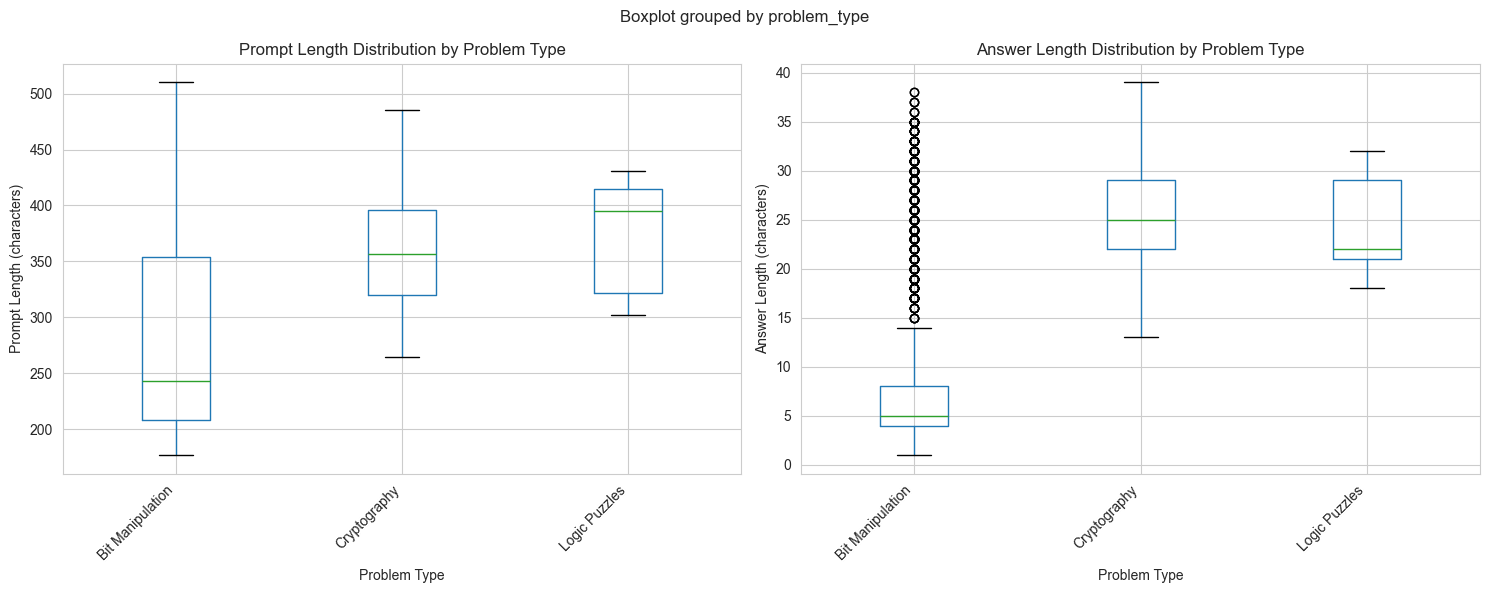

In [9]:
# Analyze complexity metrics by problem type
complexity_analysis = train_df.groupby('problem_type').agg({
    'prompt_length': ['mean', 'median', 'std'],
    'prompt_word_count': ['mean', 'median'],
    'answer_length': ['mean', 'median', 'std'],
    'answer_word_count': ['mean', 'median'],
    'id': 'count'
}).round(2)

complexity_analysis.columns = ['_'.join(col).strip() for col in complexity_analysis.columns.values]
complexity_analysis.rename(columns={'id_count': 'count'}, inplace=True)

print("=" * 80)
print("COMPLEXITY METRICS BY PROBLEM TYPE")
print("=" * 80)
print(complexity_analysis)

# Visualization: Box plots of prompt/answer lengths by problem type
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Prompt length by problem type
ax1 = axes[0]
train_df.boxplot(column='prompt_length', by='problem_type', ax=ax1)
ax1.set_title('Prompt Length Distribution by Problem Type')
ax1.set_xlabel('Problem Type')
ax1.set_ylabel('Prompt Length (characters)')
plt.sca(ax1)
plt.xticks(rotation=45, ha='right')

# Answer length by problem type
ax2 = axes[1]
train_df.boxplot(column='answer_length', by='problem_type', ax=ax2)
ax2.set_title('Answer Length Distribution by Problem Type')
ax2.set_xlabel('Problem Type')
ax2.set_ylabel('Answer Length (characters)')
plt.sca(ax2)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Section 7: Complexity Analysis by Problem Type

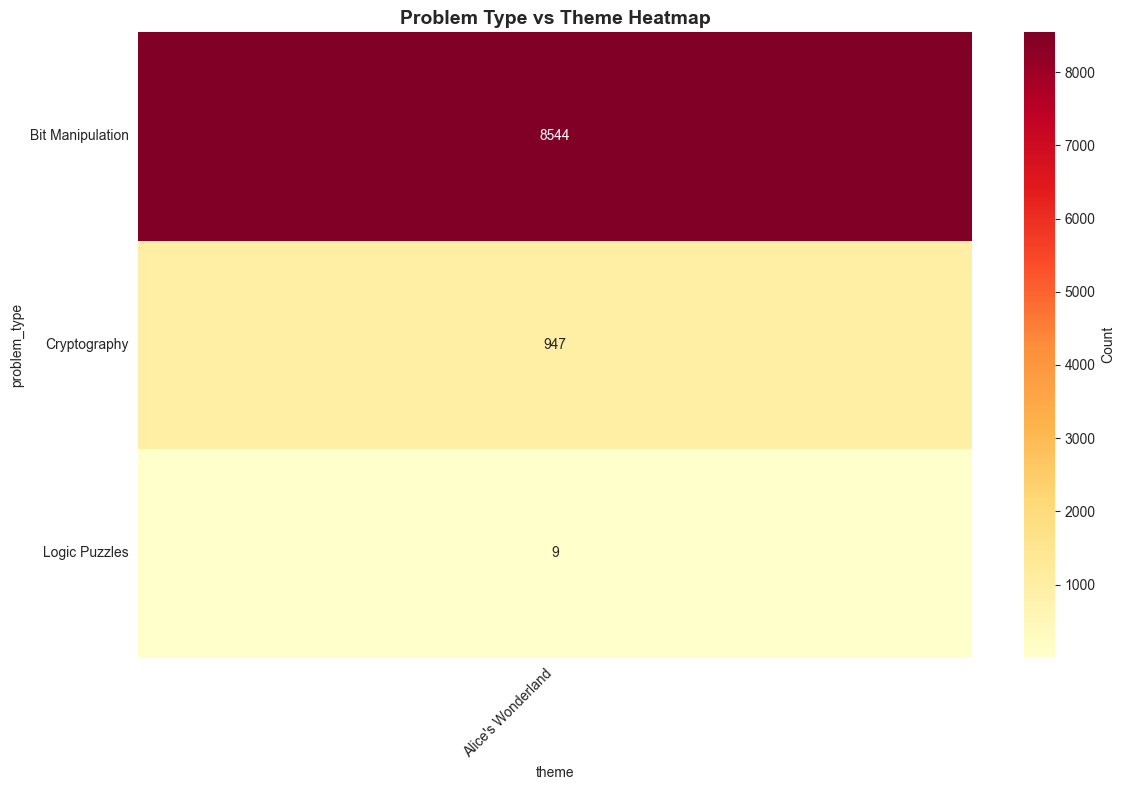

In [8]:
# Visualization 2: Heatmap of Problem Type vs Theme
fig, ax = plt.subplots(figsize=(12, 8))
crosstab_data = pd.crosstab(train_df['problem_type'], train_df['theme'])
sns.heatmap(crosstab_data, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'}, ax=ax)
ax.set_title('Problem Type vs Theme Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

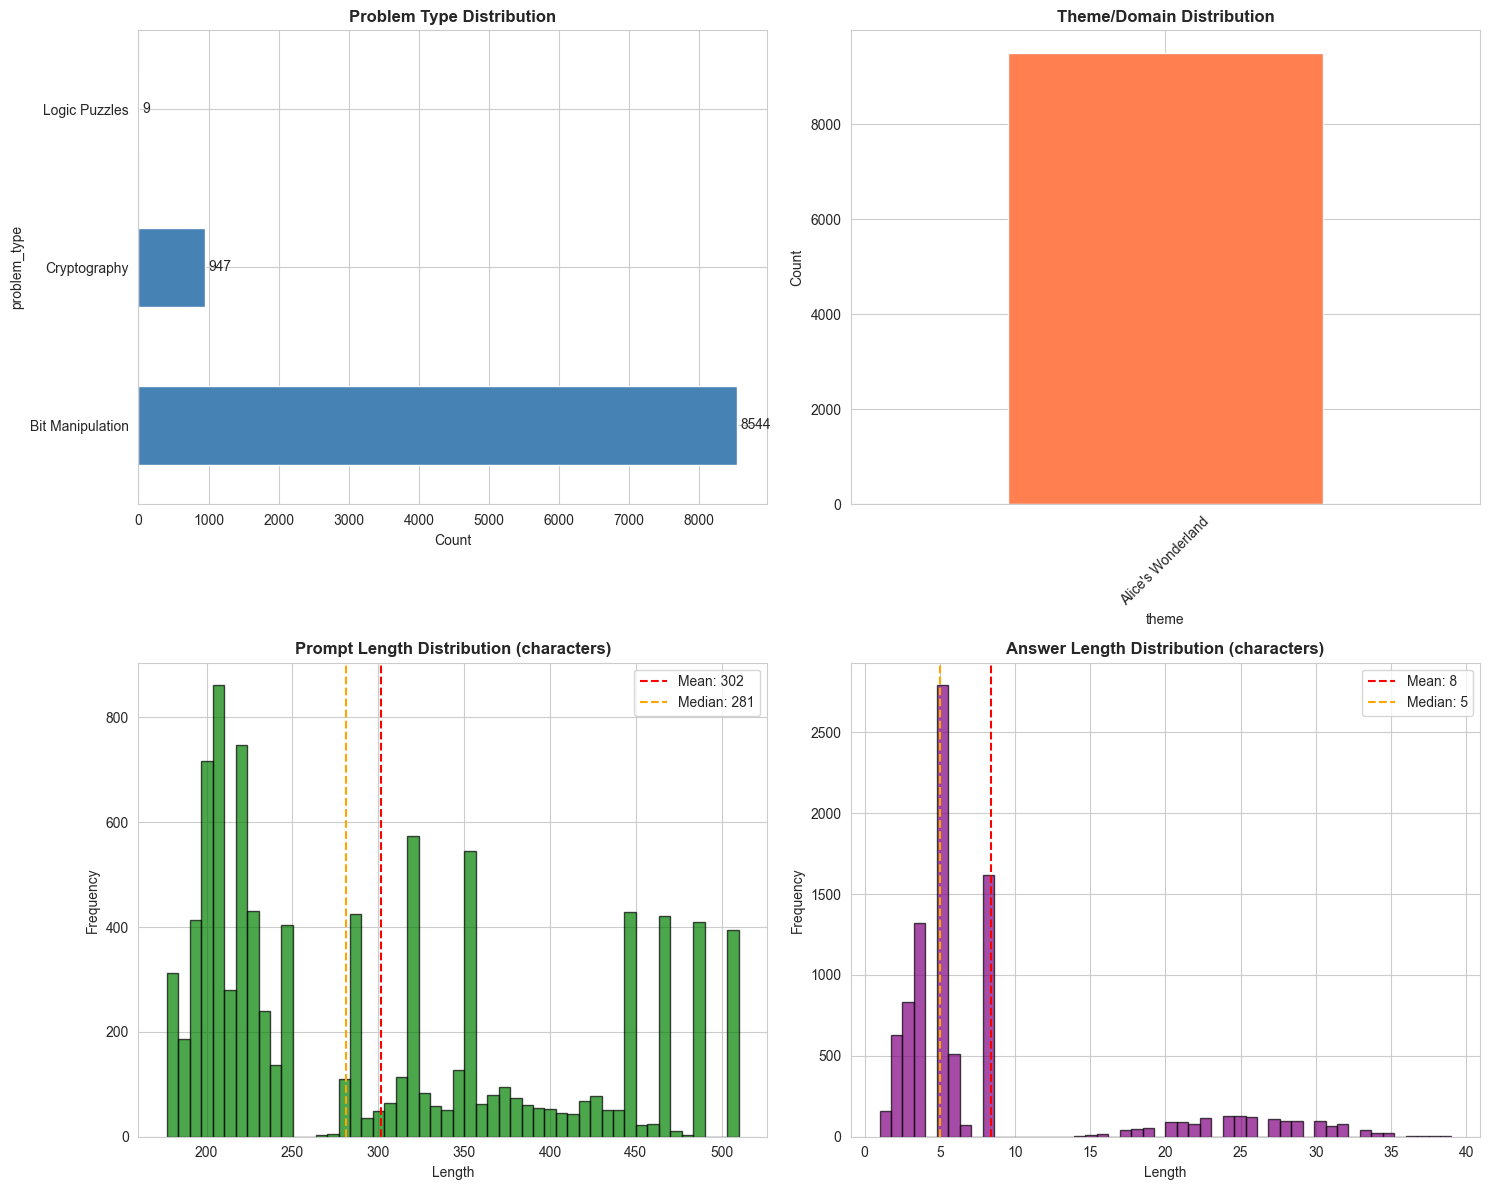

In [7]:
# Visualization 1: Problem Type Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Problem Type Bar Chart
ax1 = axes[0, 0]
problem_counts.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Problem Type Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Count')
for i, v in enumerate(problem_counts.values):
    ax1.text(v + 50, i, str(v), va='center')

# 2. Theme Distribution
ax2 = axes[0, 1]
theme_counts.plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Theme/Domain Distribution', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

# 3. Prompt Length Distribution
ax3 = axes[1, 0]
ax3.hist(train_df['prompt_length'], bins=50, color='green', alpha=0.7, edgecolor='black')
ax3.set_title('Prompt Length Distribution (characters)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Length')
ax3.set_ylabel('Frequency')
ax3.axvline(train_df['prompt_length'].mean(), color='red', linestyle='--', label=f'Mean: {train_df["prompt_length"].mean():.0f}')
ax3.axvline(train_df['prompt_length'].median(), color='orange', linestyle='--', label=f'Median: {train_df["prompt_length"].median():.0f}')
ax3.legend()

# 4. Answer Length Distribution
ax4 = axes[1, 1]
ax4.hist(train_df['answer_length'], bins=50, color='purple', alpha=0.7, edgecolor='black')
ax4.set_title('Answer Length Distribution (characters)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Length')
ax4.set_ylabel('Frequency')
ax4.axvline(train_df['answer_length'].mean(), color='red', linestyle='--', label=f'Mean: {train_df["answer_length"].mean():.0f}')
ax4.axvline(train_df['answer_length'].median(), color='orange', linestyle='--', label=f'Median: {train_df["answer_length"].median():.0f}')
ax4.legend()

plt.tight_layout()
plt.show()

## Section 6: Visualize Reasoning Type Trends

In [6]:
# Create cross-tabulation of problem types and themes
crosstab = pd.crosstab(train_df['problem_type'], train_df['theme'], margins=True)
print("=" * 60)
print("PROBLEM TYPE vs THEME CO-OCCURRENCE")
print("=" * 60)
print(crosstab)

# Find most common problem type + theme combinations
combinations = train_df.groupby(['problem_type', 'theme']).size().reset_index(name='count').sort_values('count', ascending=False)
print("\n" + "=" * 60)
print("TOP 15 PROBLEM TYPE + THEME COMBINATIONS")
print("=" * 60)
print(combinations.head(15))

PROBLEM TYPE vs THEME CO-OCCURRENCE
theme             Alice's Wonderland   All
problem_type                              
Bit Manipulation                8544  8544
Cryptography                     947   947
Logic Puzzles                      9     9
All                             9500  9500

TOP 15 PROBLEM TYPE + THEME COMBINATIONS
       problem_type               theme  count
0  Bit Manipulation  Alice's Wonderland   8544
1      Cryptography  Alice's Wonderland    947
2     Logic Puzzles  Alice's Wonderland      9


## Section 5: Analyze Co-occurring Patterns

In [5]:
# Extract opening themes/domains from prompts
def extract_theme(prompt_text):
    """Extract the domain/theme from the first sentence"""
    # Get first sentence
    first_sentence = prompt_text.split('.')[0].lower()
    
    # Check for specific domains
    if any(word in first_sentence for word in ['alice', 'wonderland', 'secret', 'transformation']):
        return 'Alice\'s Wonderland'
    elif any(word in first_sentence for word in ['dragon', 'knight', 'quest', 'treasure']):
        return 'Fantasy/Adventure'
    elif any(word in first_sentence for word in ['city', 'map', 'route', 'travel']):
        return 'Geography/Navigation'
    elif any(word in first_sentence for word in ['robot', 'ai', 'computer', 'machine']):
        return 'Technology/AI'
    elif any(word in first_sentence for word in ['music', 'song', 'note', 'symphony']):
        return 'Music/Arts'
    elif any(word in first_sentence for word in ['number', 'digit', 'count', 'mathematical']):
        return 'Mathematics'
    else:
        return 'General/Other'

train_df['theme'] = train_df['prompt'].apply(extract_theme)

print("=" * 60)
print("DOMAIN/THEME DISTRIBUTION")
print("=" * 60)
theme_counts = train_df['theme'].value_counts()
print(theme_counts)
print(f"\nPercentage distribution:")
print((theme_counts / len(train_df) * 100).round(2))

DOMAIN/THEME DISTRIBUTION
theme
Alice's Wonderland    9500
Name: count, dtype: int64

Percentage distribution:
theme
Alice's Wonderland    100.0
Name: count, dtype: float64


## Section 4: Extract Domain Themes

In [4]:
# Define problem type classifiers based on keywords
problem_types = {
    'Bit Manipulation': ['bit', 'binary', 'shift', 'rotation', 'xor', 'and', 'or', 'not'],
    'Logic Puzzles': ['puzzle', 'logic', 'rule', 'pattern', 'sequence'],
    'Mathematical': ['math', 'equation', 'calculate', 'number', 'sum', 'product', 'prime', 'divisor'],
    'Cryptography': ['cipher', 'decrypt', 'encrypt', 'code', 'secret'],
    'Sequence Analysis': ['sequence', 'series', 'pattern', 'next', 'continue'],
    'Word/Language': ['word', 'letter', 'anagram', 'spell', 'language'],
    'Reasoning': ['reason', 'deduce', 'infer', 'logic', 'conclusion'],
    'Geometry': ['shape', 'angle', 'distance', 'geometry', 'coordinate'],
    'Graph/Network': ['graph', 'node', 'edge', 'path', 'network', 'tree'],
    'Game/Strategy': ['game', 'strategy', 'play', 'move', 'win'],
}

def classify_problem(prompt_text):
    """Classify problem type based on keywords in prompt"""
    prompt_lower = prompt_text.lower()
    
    # Find matching categories
    matches = {}
    for category, keywords in problem_types.items():
        score = sum(prompt_lower.count(keyword) for keyword in keywords)
        if score > 0:
            matches[category] = score
    
    # Return the highest scoring category
    if matches:
        return max(matches, key=matches.get)
    else:
        return 'Other/Unclassified'

# Classify all problems
train_df['problem_type'] = train_df['prompt'].apply(classify_problem)

print("=" * 60)
print("PROBLEM TYPE DISTRIBUTION")
print("=" * 60)
problem_counts = train_df['problem_type'].value_counts()
print(problem_counts)
print(f"\nPercentage distribution:")
print((problem_counts / len(train_df) * 100).round(2))

PROBLEM TYPE DISTRIBUTION
problem_type
Bit Manipulation    8544
Cryptography         947
Logic Puzzles          9
Name: count, dtype: int64

Percentage distribution:
problem_type
Bit Manipulation    89.94
Cryptography         9.97
Logic Puzzles        0.09
Name: count, dtype: float64


## Section 3: Classify Problem Types by Keywords

In [3]:
# Analyze prompt characteristics
train_df['prompt_length'] = train_df['prompt'].str.len()
train_df['prompt_word_count'] = train_df['prompt'].str.split().str.len()
train_df['answer_length'] = train_df['answer'].str.len()
train_df['answer_word_count'] = train_df['answer'].str.split().str.len()

print("=" * 60)
print("PROMPT AND ANSWER STATISTICS")
print("=" * 60)
print("\nPrompt Length (characters):")
print(train_df['prompt_length'].describe())
print("\nPrompt Word Count:")
print(train_df['prompt_word_count'].describe())
print("\nAnswer Length (characters):")
print(train_df['answer_length'].describe())
print("\nAnswer Word Count:")
print(train_df['answer_word_count'].describe())

PROMPT AND ANSWER STATISTICS

Prompt Length (characters):
count    9500.000000
mean      301.515895
std       104.265311
min       177.000000
25%       209.000000
50%       281.000000
75%       371.000000
max       510.000000
Name: prompt_length, dtype: float64

Prompt Word Count:
count    9500.000000
mean       50.042947
std        14.305601
min        32.000000
25%        36.000000
50%        46.000000
75%        65.000000
max        78.000000
Name: prompt_word_count, dtype: float64

Answer Length (characters):
count    9500.000000
mean        8.393789
std         8.035097
min         1.000000
25%         4.000000
50%         5.000000
75%         8.000000
max        39.000000
Name: answer_length, dtype: float64

Answer Word Count:
count    9500.000000
mean        1.499474
std         1.155232
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         5.000000
Name: answer_word_count, dtype: float64


## Section 2: Analyze Prompt Characteristics

In [2]:
# Load datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("=" * 60)
print("TRAINING DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {train_df.shape}")
print(f"\nColumn names and types:")
print(train_df.dtypes)
print(f"\nMissing values:")
print(train_df.isnull().sum())
print(f"\nFirst few rows:")
print(train_df.head())

print("\n" + "=" * 60)
print("TEST DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {test_df.shape}")
print(f"\nFirst few rows:")
print(test_df.head())

TRAINING DATASET OVERVIEW
Shape: (9500, 3)

Column names and types:
id        str
prompt    str
answer    str
dtype: object

Missing values:
id        0
prompt    0
answer    0
dtype: int64

First few rows:
         id                                             prompt  \
0  00066667  In Alice's Wonderland, a secret bit manipulati...   
1  000b53cf  In Alice's Wonderland, a secret bit manipulati...   
2  00189f6a  In Alice's Wonderland, secret encryption rules...   
3  001b24c4  In Alice's Wonderland, numbers are secretly co...   
4  001c63cb  In Alice's Wonderland, secret encryption rules...   

                  answer  
0               10010111  
1               01000011  
2      cat imagines book  
3                XXXVIII  
4  wizard creates secret  

TEST DATASET OVERVIEW
Shape: (3, 2)

First few rows:
         id                                             prompt
0  00066667  In Alice's Wonderland, a secret bit manipulati...
1  000b53cf  In Alice's Wonderland, a secret bit manip

## Section 1: Load and Inspect the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# NVIDIA Nemotron Reasoning Challenge - Data Analysis

This notebook explores the reasoning problem types, patterns, and characteristics in the challenge dataset. We'll analyze problem distributions, identify common reasoning patterns, and visualize key insights.